In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("train-test.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


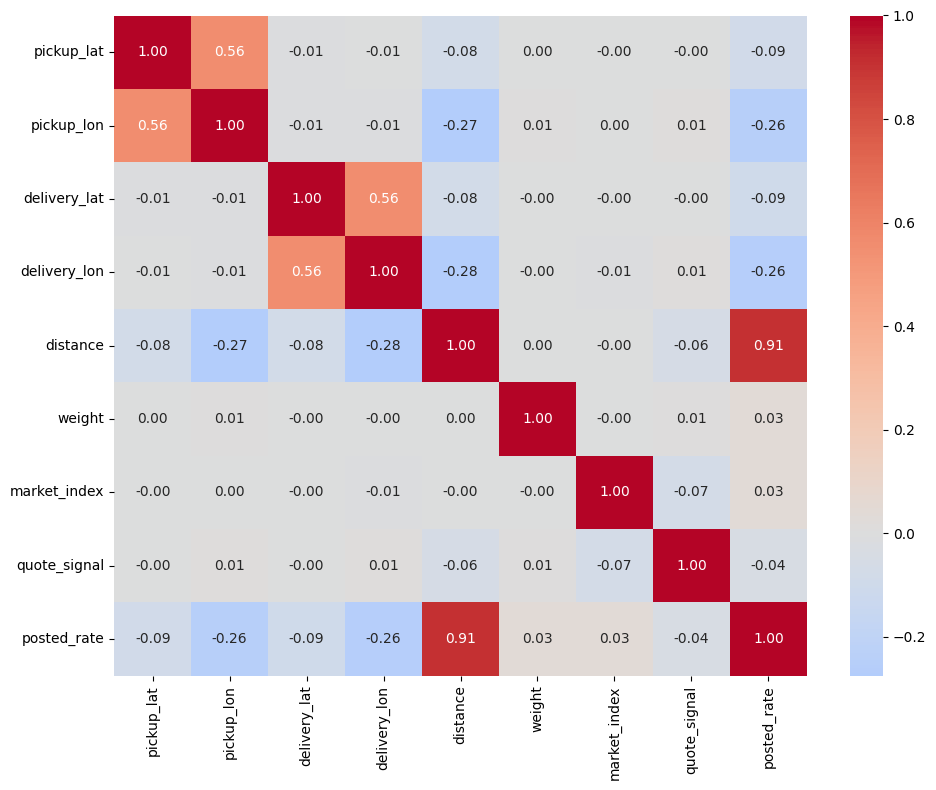

In [5]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

In [6]:

n_pick, n_del = df['pickup'].nunique(), df['delivery'].nunique()
print("pickup cities  :", n_pick)
print("delivery cities:", n_del)


pickup cities  : 64
delivery cities: 64


Hence doing a one hot encoding will not be efficent 

In [7]:
df['date'] = pd.to_datetime(df['date'])

#
# One-hot encode equipment
equipment_encoded = pd.get_dummies(df['equipment'], prefix='equipment', dtype=int)

# Add the new columns to the original df
df = pd.concat([df, equipment_encoded], axis=1)

# Correlation
corr_with_rate = df.corr(numeric_only=True)['posted_rate'].sort_values(ascending=False)

# Print only equipment correlations
equipment_corr = corr_with_rate[corr_with_rate.index.str.startswith('equipment_')]
print(equipment_corr)

equipment_Reefer     0.069953
equipment_Flatbed    0.022591
equipment_Dry Van   -0.078807
Name: posted_rate, dtype: float64


In [8]:
cols = [c for c in df.columns if c != 'load_id']

# keep=False marks every row in a duplicate group, so you can see them all
dups = df[df.duplicated(subset=cols, keep=False)]
print("rows involved in duplicates:", len(dups))
print("extra copies that would be removed:", df.duplicated(subset=cols).sum())

# If any exist, inspect them, then remove (keep the first of each group):
# df = df.drop_duplicates(subset=cols, keep='first')

rows involved in duplicates: 0
extra copies that would be removed: 0


In [9]:
df['date'] = pd.to_datetime(df['date'])

# Extract temporal features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_month'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek

In [10]:

# negative weights are sign flips, so take the absolute value
print("negative weights:", (df['weight'] < 0).sum())
df['weight'] = df['weight'].abs()

# fill missing with the median (after the abs fix)
weight_median = df['weight'].median()
print("missing weight:", df['weight'].isna().sum(), "| median used:", weight_median)
df['weight'] = df['weight'].fillna(weight_median)

negative weights: 292
missing weight: 300 | median used: 31496.0


Correlations with posted_rate:
Day of Month: 0.0103
Day of Week: -0.0034
Month: 0.0238
Quote Signal: -0.0399

Market Index correlation with rate: 0.0342


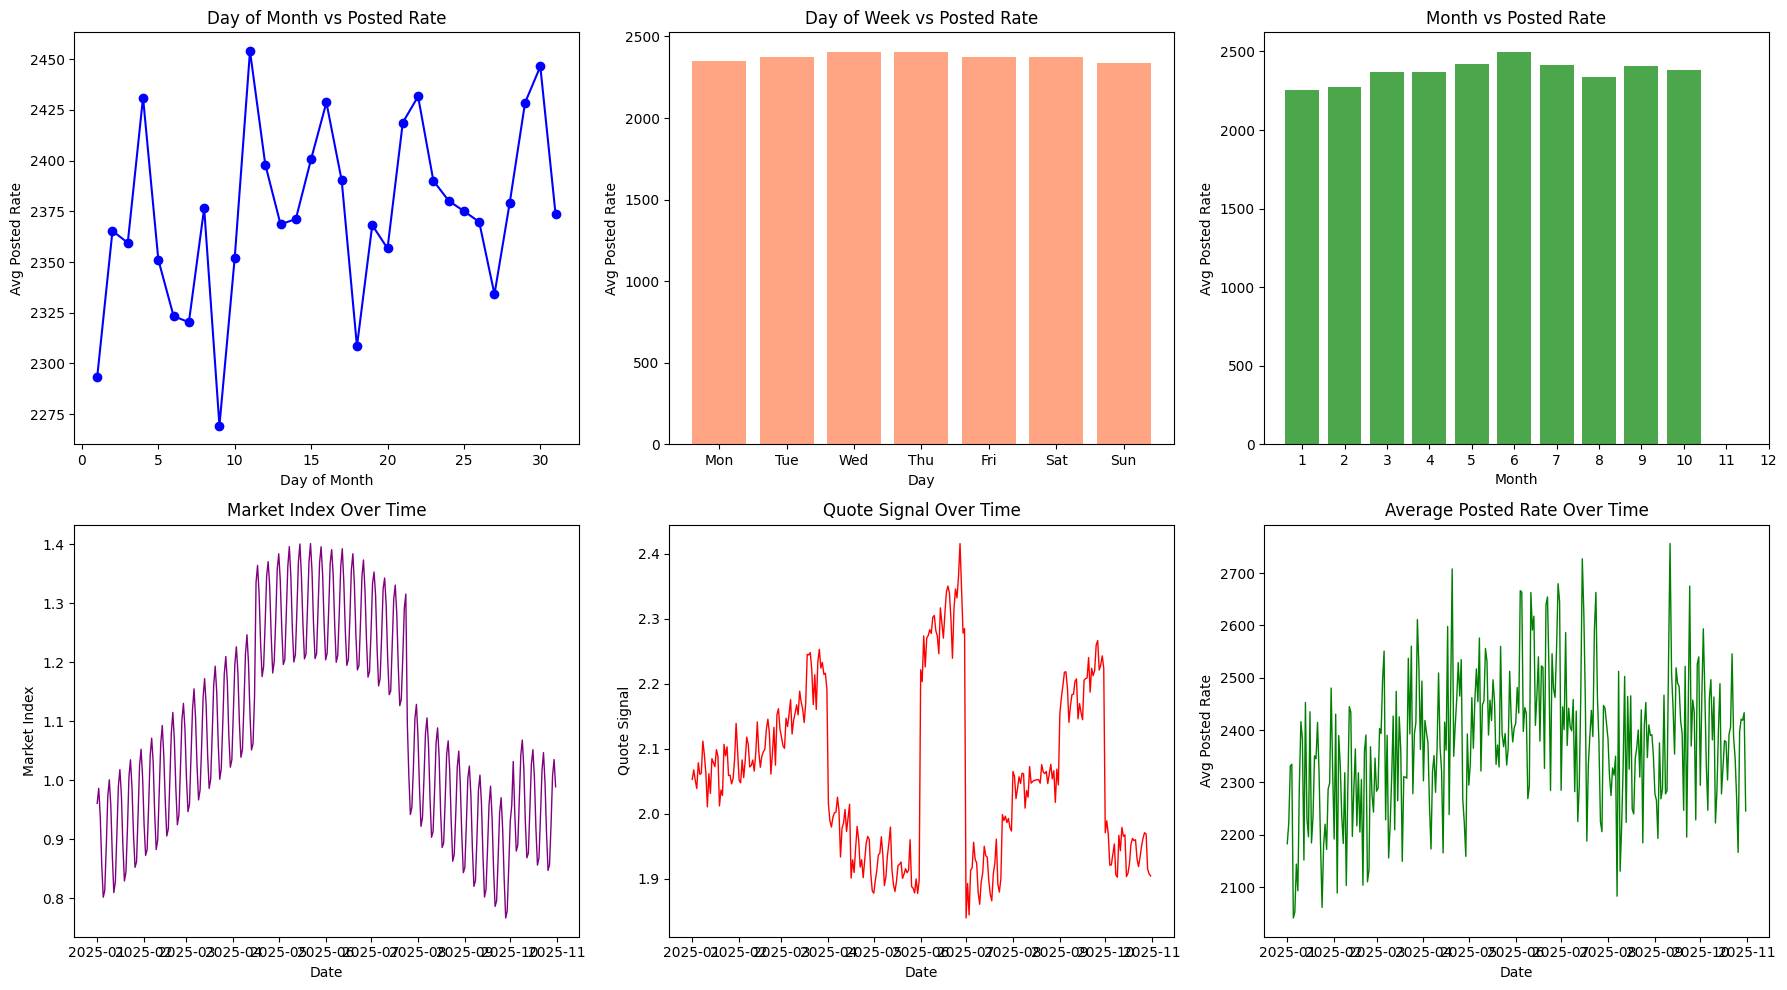

In [11]:


# ========== CORRELATIONS ==========
print("Correlations with posted_rate:")
print(f"Day of Month: {df['day_of_month'].corr(df['posted_rate']):.4f}")
print(f"Day of Week: {df['day_of_week'].corr(df['posted_rate']):.4f}")
print(f"Month: {df['month'].corr(df['posted_rate']):.4f}")
print(f"Quote Signal: {df['quote_signal'].corr(df['posted_rate']):.4f}")
print(f"\nMarket Index correlation with rate: {df['market_index'].corr(df['posted_rate']):.4f}")

# ========== VISUALIZATIONS ==========
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Day of month
day_of_month_avg = df.groupby('day_of_month')['posted_rate'].mean()
axes[0, 0].plot(day_of_month_avg.index, day_of_month_avg.values, marker='o', color='blue')
axes[0, 0].set_title('Day of Month vs Posted Rate')
axes[0, 0].set_xlabel('Day of Month')
axes[0, 0].set_ylabel('Avg Posted Rate')

# Day of week
dow_avg = df.groupby('day_of_week')['posted_rate'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0, 1].bar(dow_avg.index, dow_avg.values, color='coral', alpha=0.7)
axes[0, 1].set_title('Day of Week vs Posted Rate')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(days)
axes[0, 1].set_ylabel('Avg Posted Rate')

# Month
month_avg = df.groupby('month')['posted_rate'].mean()
axes[0, 2].bar(month_avg.index, month_avg.values, color='green', alpha=0.7)
axes[0, 2].set_title('Month vs Posted Rate')
axes[0, 2].set_xlabel('Month')
axes[0, 2].set_xticks(range(1, 13))
axes[0, 2].set_ylabel('Avg Posted Rate')

# Market index over time
daily_market = df.groupby('date')['market_index'].mean()
axes[1, 0].plot(daily_market.index, daily_market.values, linewidth=1, color='purple')
axes[1, 0].set_title('Market Index Over Time')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Market Index')

# Quote signal over time
daily_quote = df.groupby('date')['quote_signal'].mean()
axes[1, 1].plot(daily_quote.index, daily_quote.values, linewidth=1, color='red')
axes[1, 1].set_title('Quote Signal Over Time')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Quote Signal')

# Posted rate over time
daily_rate = df.groupby('date')['posted_rate'].mean()
axes[1, 2].plot(daily_rate.index, daily_rate.values, linewidth=1, color='green')
axes[1, 2].set_title('Average Posted Rate Over Time')
axes[1, 2].set_xlabel('Date')
axes[1, 2].set_ylabel('Avg Posted Rate')

plt.tight_layout()
plt.savefig('temporal_market_analysis.png', dpi=300)
plt.show()

In [12]:
#addthe mark with week plot

Weekday effect (0=Mon):
 date
0   -0.084
1   -0.011
2    0.072
3    0.099
4    0.050
5   -0.035
6   -0.096
Name: market_index, dtype: float64


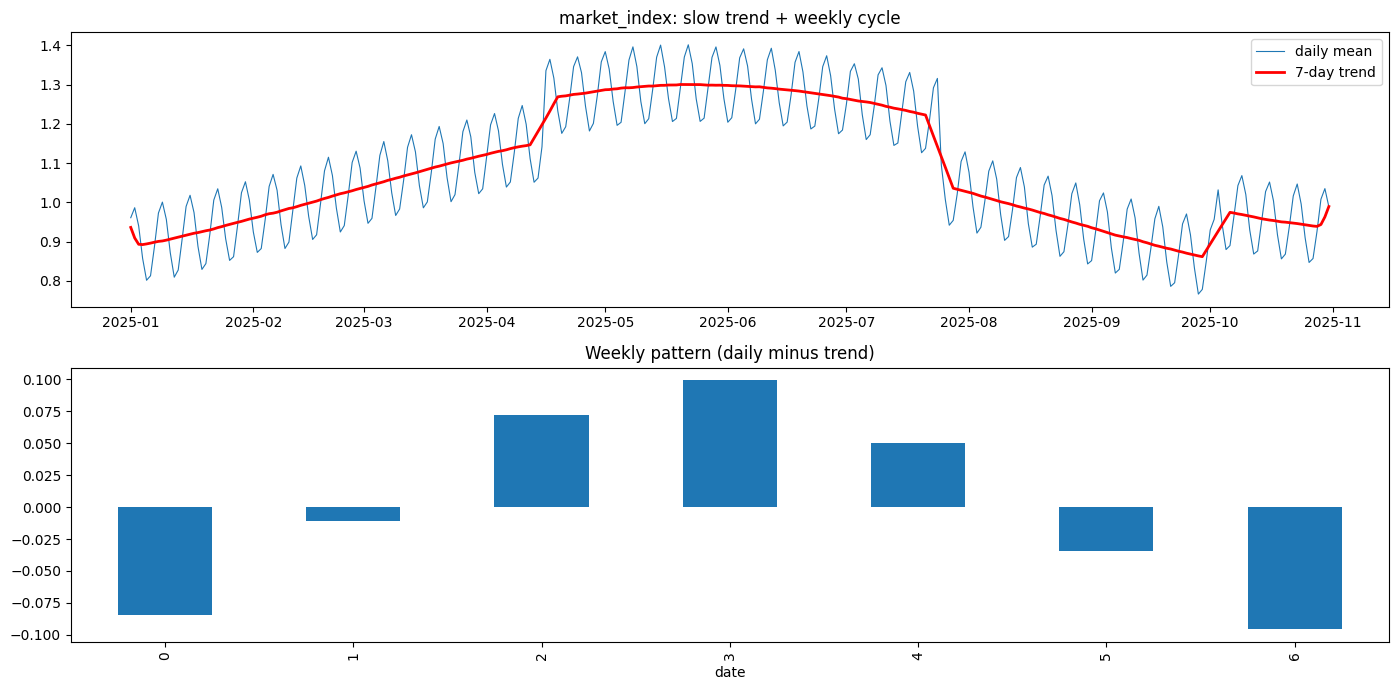


Mean abs error when refilling a known value:
  same-day average of other loads: 0.02
  global median                  : 0.1426


In [13]:
import numpy as np

# One value per day: market_index barely varies within a day
daily = df.groupby('date')['market_index'].mean().asfreq('D')

# Weekly pattern = daily value minus its 7-day average
trend = daily.rolling(7, center=True, min_periods=4).mean()
weekday_profile = (daily - trend).groupby(daily.index.dayofweek).mean()
print("Weekday effect (0=Mon):\n", weekday_profile.round(3))

fig, ax = plt.subplots(2, 1, figsize=(14, 7))
ax[0].plot(daily, lw=0.8, label='daily mean'); ax[0].plot(trend, color='red', lw=2, label='7-day trend')
ax[0].legend(); ax[0].set_title('market_index: slow trend + weekly cycle')
weekday_profile.plot(kind='bar', ax=ax[1]); ax[1].set_title('Weekly pattern (daily minus trend)')
plt.tight_layout(); plt.show()

# Test fill methods: hide known values, rebuild them, measure the error
known = df.dropna(subset=['market_index']).copy()
g = known.groupby('date')['market_index']
known['same_day'] = (g.transform('sum') - known['market_index']) / (g.transform('count') - 1)

print("\nMean abs error when refilling a known value:")
print("  same-day average of other loads:", round((known['same_day'] - known['market_index']).abs().mean(), 4))
print("  global median                  :", round((known['market_index'].median() - known['market_index']).abs().mean(), 4))

In [14]:
# 1) Main method: the same date's other loads
day_median = df.groupby('date')['market_index'].transform('median')
df['market_index'] = df['market_index'].fillna(day_median)

# 2) Fallback for a date with no values at all: neighbor-day trend + weekday effect
still = df['market_index'].isna()
if still.any():
    daily_filled = daily.interpolate()
    trend_f = daily_filled.rolling(7, center=True, min_periods=4).mean()
    est = trend_f + pd.Series(weekday_profile.reindex(daily.index.dayofweek).values, index=daily.index)
    df.loc[still, 'market_index'] = df.loc[still, 'date'].map(est)

print("remaining missing:", df[['weight', 'market_index']].isna().sum().to_dict())

remaining missing: {'weight': 0, 'market_index': 0}


held-out rows: 2446 | MAE: 0.0204 | 95th pct error: 0.0504


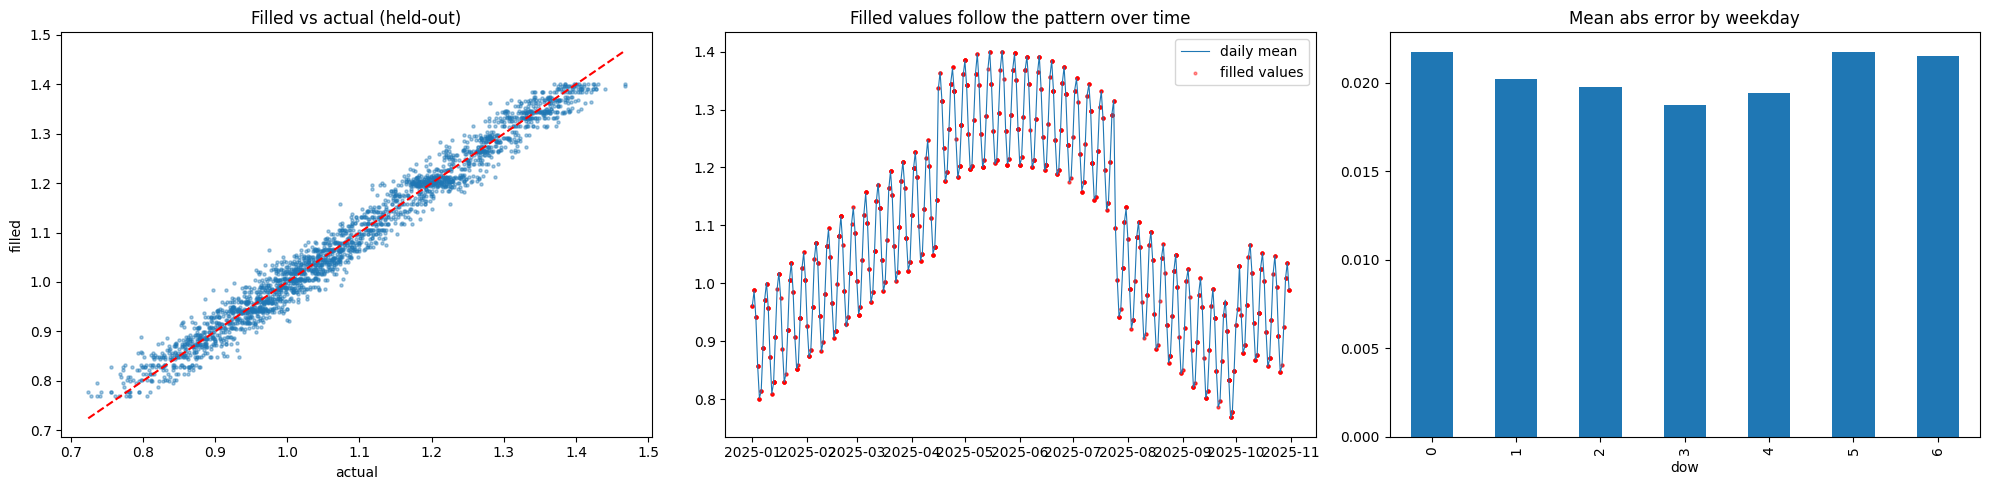

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Start from the ORIGINAL values (before filling); reload if you already filled df
orig = pd.read_csv("train-test.csv", parse_dates=['date'])
known = orig.dropna(subset=['market_index']).copy()

# Hold out 5% of the known values and pretend they're missing
rng = np.random.RandomState(0)
hold = rng.rand(len(known)) < 0.05
test = known[hold].copy()
rest = known[~hold]

# Fill the held-out rows with the same-day median of the remaining loads
day_med = rest.groupby('date')['market_index'].median()
test['filled'] = test['date'].map(day_med)
test = test.dropna(subset=['filled'])

err = (test['filled'] - test['market_index']).abs()
print(f"held-out rows: {len(test)} | MAE: {err.mean():.4f} | 95th pct error: {err.quantile(.95):.4f}")

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# 1) Filled vs actual: points should sit on the diagonal
ax[0].scatter(test['market_index'], test['filled'], s=5, alpha=0.4)
lims = [test['market_index'].min(), test['market_index'].max()]
ax[0].plot(lims, lims, 'r--'); ax[0].set_xlabel('actual'); ax[0].set_ylabel('filled')
ax[0].set_title('Filled vs actual (held-out)')

# 2) Over time: actual daily curve with filled points on top
daily = known.groupby('date')['market_index'].mean()
ax[1].plot(daily.index, daily.values, lw=0.8, label='daily mean')
ax[1].scatter(test['date'], test['filled'], s=4, color='red', alpha=0.4, label='filled values')
ax[1].legend(); ax[1].set_title('Filled values follow the pattern over time')

# 3) Error by weekday: should be flat if the weekly cycle is captured
(test.assign(dow=test['date'].dt.dayofweek, e=err)
     .groupby('dow')['e'].mean().plot(kind='bar', ax=ax[2]))
ax[2].set_title('Mean abs error by weekday')
plt.tight_layout(); plt.show()

In [16]:
# Rate per mile = the model's target
df['rpm'] = df['posted_rate'] / df['distance']

# Flag label outliers (don't drop yet; we drop from TRAIN only, after the split)
df['rpm_outlier'] = ~df['rpm'].between(1.2, 4.0)

print(df['rpm'].describe().round(3))
print("flagged outliers:", df['rpm_outlier'].sum(), f"({df['rpm_outlier'].mean():.2%})")

count    48000.000
mean         2.215
std          0.584
min          0.334
25%          1.987
50%          2.145
75%          2.343
max         14.125
Name: rpm, dtype: float64
flagged outliers: 675 (1.41%)


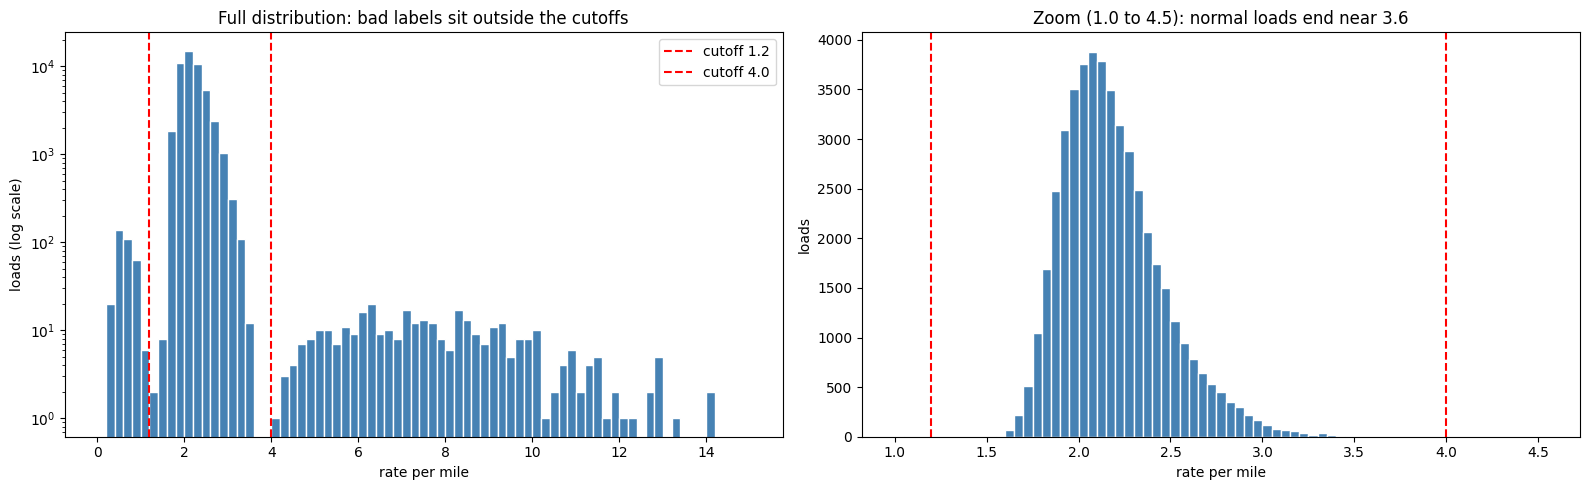

below cutoff: 335 | above cutoff: 340 | total flagged: 1.41%


In [17]:
import numpy as np
import matplotlib.pyplot as plt

LOW, HIGH = 1.2, 4.0
r = df['rpm']

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# 1) Full range, log scale: shows the corrupted clusters
bins = np.arange(0, 15.2, 0.2)
ax[0].hist(r, bins=bins, color='steelblue', edgecolor='white')
ax[0].set_yscale('log')
ax[0].axvline(LOW, color='red', ls='--', label=f'cutoff {LOW}')
ax[0].axvline(HIGH, color='red', ls='--', label=f'cutoff {HIGH}')
ax[0].set_xlabel('rate per mile'); ax[0].set_ylabel('loads (log scale)')
ax[0].set_title('Full distribution: bad labels sit outside the cutoffs')
ax[0].legend()

# 2) Zoom on the real data: shows the sharp edges and the empty gaps
ax[1].hist(r[r.between(1.0, 4.5)], bins=np.arange(1.0, 4.6, 0.05), color='steelblue', edgecolor='white')
ax[1].axvline(LOW, color='red', ls='--'); ax[1].axvline(HIGH, color='red', ls='--')
ax[1].set_xlabel('rate per mile'); ax[1].set_ylabel('loads')
ax[1].set_title('Zoom (1.0 to 4.5): normal loads end near 3.6')

plt.tight_layout()
plt.savefig('rpm_distribution.png', dpi=200)
plt.show()

print("below cutoff:", (r < LOW).sum(), "| above cutoff:", (r > HIGH).sum(),
      f"| total flagged: {((r < LOW) | (r > HIGH)).mean():.2%}")

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   load_id            48000 non-null  object        
 1   pickup             48000 non-null  object        
 2   delivery           48000 non-null  object        
 3   pickup_lat         48000 non-null  float64       
 4   pickup_lon         48000 non-null  float64       
 5   delivery_lat       48000 non-null  float64       
 6   delivery_lon       48000 non-null  float64       
 7   distance           48000 non-null  float64       
 8   equipment          48000 non-null  object        
 9   weight             48000 non-null  float64       
 10  date               48000 non-null  datetime64[ns]
 11  market_index       48000 non-null  float64       
 12  quote_signal       48000 non-null  float64       
 13  posted_rate        48000 non-null  float64       
 14  equipm

In [19]:
df_selected = df[
    [
        'rpm',
        'rpm_outlier',
        'day_of_week',
        'day_of_month',
        'equipment_Dry Van',
        'equipment_Flatbed',
        'equipment_Reefer',
        'month',
        'posted_rate',
        'quote_signal',
        'market_index',
        'weight',
        'distance'
    ]
]


Feature: rpm
Number of outliers: 1634
Lower bound: 1.45
Upper bound: 2.88
Outlier values:
[0.5645629965947787, 0.7663513807349424, 2.9597037037037035, 0.7559947491248541, 6.665236938031591, 0.699594834135224, 5.038615791672469, 0.35388079336166767, 5.325397562391178, 2.940530759951749, 2.9347076461769115, 13.315575916230365, 0.4708333333333333, 2.89425, 2.889205702647658, 0.4876777251184834, 7.983558426306517, 0.6516788465336757, 6.17742802303263, 2.9024539877300612, 5.9644939101217975, 0.700063492063492, 12.663773965691222, 7.310544328552803, 3.3655714285714287, 8.664827709978464, 0.6777897990726429, 0.377407867494824, 0.7099964330301409, 7.242745497791369, 2.881064483111566, 3.2102857142857144, 0.7854712643678161, 4.981032138000144, 8.232237896761784, 0.8130222944042522, 6.06345013477089, 9.85818181818182, 0.5275047962100152, 6.00016339869281, 9.613532287110884, 9.000431419220469, 0.4779447960618847, 2.8887166236003448, 3.0309718437783832, 2.9636965683323298, 3.029638364779874, 11.3

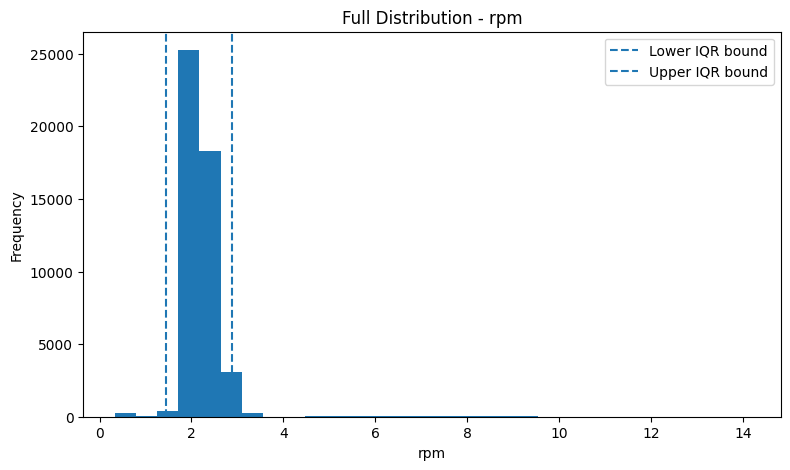

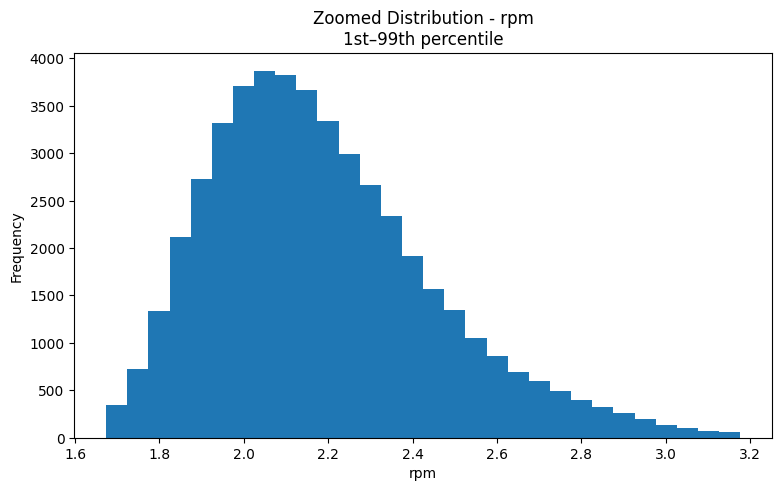


Feature: posted_rate
Number of outliers: 260
Lower bound: -1867.24
Upper bound: 6449.54
Outlier values:
[10854.69, 7100.73, 24140.21, 13918.0, 10270.54, 11210.34, 12100.18, 9313.19, 10436.26, 7679.26, 12854.51, 22534.65, 8339.05, 9275.66, 8552.48, 17688.63, 14536.22, 9080.04, 7772.01, 6546.69, 6494.7, 8091.49, 9457.25, 9825.71, 10945.08, 10115.44, 10537.71, 6646.55, 6577.86, 8453.3, 6601.62, 7214.86, 10036.5, 12422.22, 7768.03, 10769.23, 6766.64, 11247.8, 10168.3, 12454.19, 7177.73, 25533.0, 7498.05, 6693.1, 6777.67, 6856.28, 8549.6, 6621.13, 6486.17, 6599.27, 6662.34, 6519.03, 16386.16, 6581.92, 8401.52, 8631.33, 7648.0, 7106.91, 11408.87, 6653.67, 11311.81, 23662.71, 13847.57, 12750.46, 16841.6, 6780.59, 6464.93, 6489.53, 6602.57, 6493.55, 6841.2, 8708.21, 14934.48, 7777.29, 9161.37, 6719.59, 6566.74, 16229.57, 6750.59, 6861.2, 17772.53, 6538.24, 6628.46, 6459.05, 6576.53, 12906.22, 14561.21, 9350.63, 12569.71, 6667.69, 14079.19, 11708.49, 7010.39, 13863.47, 6520.35, 6822.84, 11895.

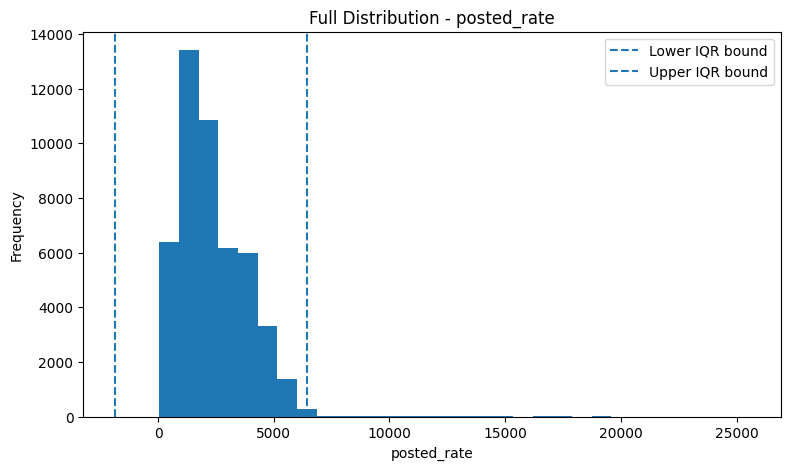

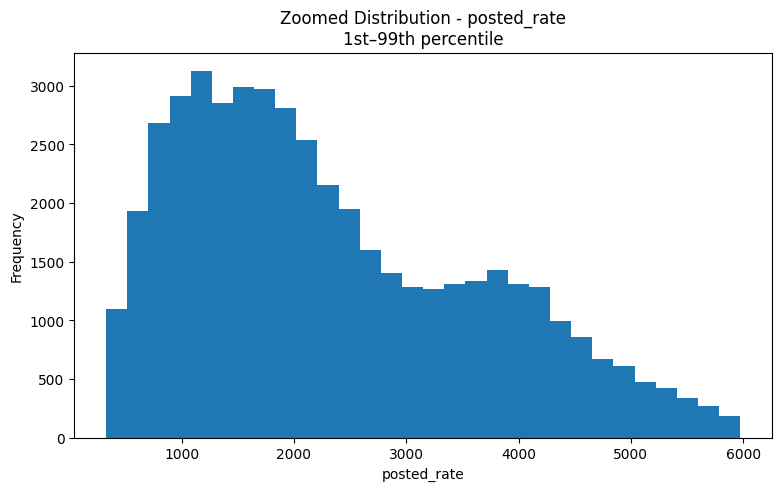


Feature: quote_signal
Number of outliers: 1956
Lower bound: 1.40
Upper bound: 2.72
Outlier values:
[2.79934, 2.93631, 2.80354, 2.78342, 2.76336, 2.85573, 2.76405, 2.79356, 2.93462, 2.90558, 2.92545, 2.91099, 2.74272, 2.7353, 2.77328, 2.78301, 2.88395, 2.71957, 2.73991, 2.76337, 2.76228, 2.75401, 2.78811, 2.764, 3.36465, 2.7556, 2.90564, 2.86239, 2.74682, 3.22762, 2.73603, 2.74924, 2.7396, 2.87091, 2.85803, 2.75644, 2.87584, 3.01763, 2.9595, 3.04317, 2.87753, 2.84121, 2.81341, 2.85054, 2.75955, 2.74863, 2.75347, 3.03401, 2.76769, 2.84191, 2.74405, 2.96322, 2.73443, 2.73598, 3.0358, 2.78351, 2.76056, 2.81634, 2.83075, 2.90001, 2.75621, 2.87921, 2.94244, 2.96093, 2.79979, 2.72702, 2.89114, 2.81384, 2.82357, 2.86128, 3.25459, 2.81459, 2.75457, 3.05078, 2.99691, 2.99005, 2.91846, 2.84099, 2.77358, 2.76587, 2.76994, 2.73027, 2.72582, 3.02679, 2.72774, 2.77502, 2.76035, 2.95691, 2.91227, 2.90385, 2.74728, 2.91168, 2.95606, 2.82713, 2.96407, 3.03904, 2.83865, 2.9801, 2.75181, 2.77789, 2.8429,

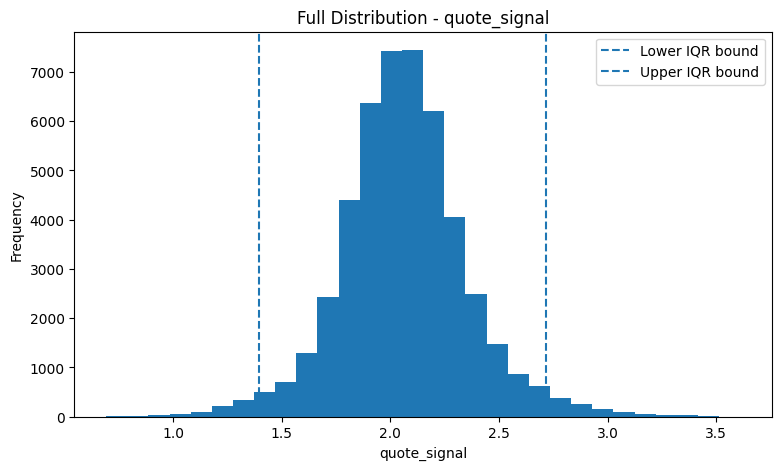

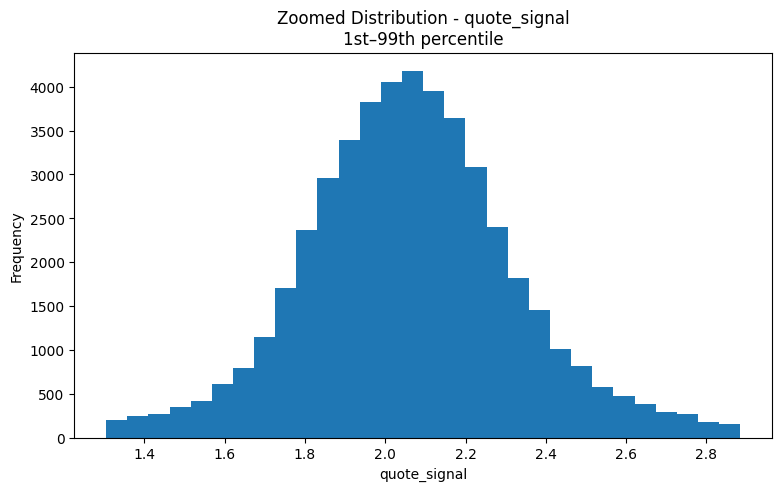


Feature: market_index
Number of outliers: 0
Lower bound: 0.54
Upper bound: 1.62
Outlier values:
[]


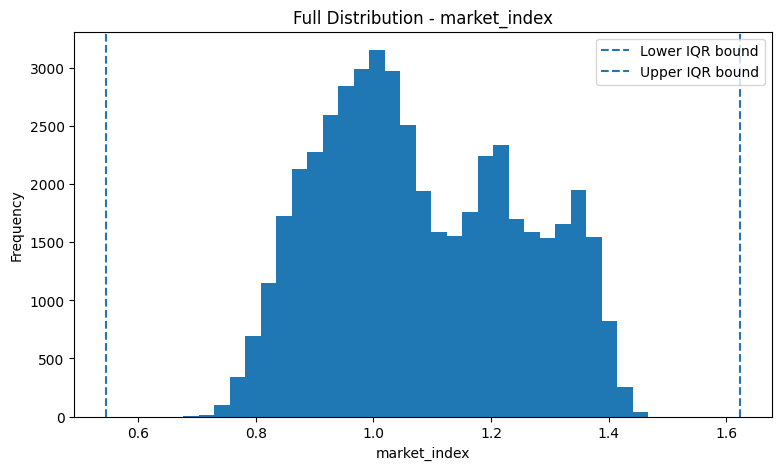

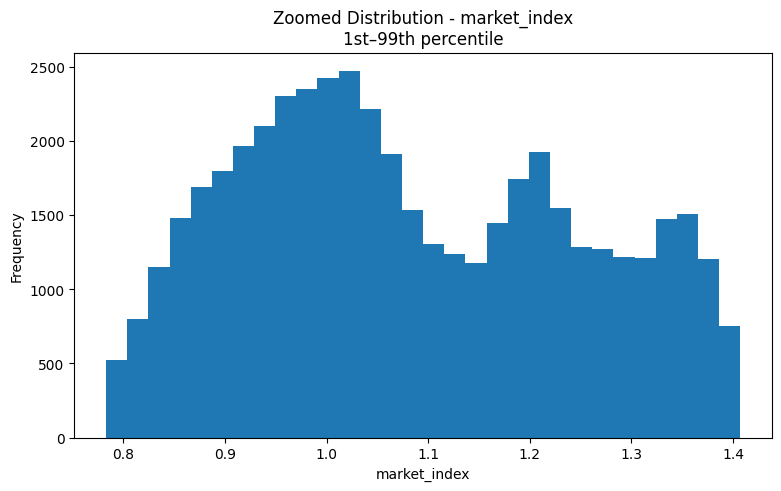


Feature: weight
Number of outliers: 164
Lower bound: 9375.50
Upper bound: 53603.50
Outlier values:
[8769.0, 6811.0, 7856.0, 7924.0, 6798.0, 8212.0, 9293.0, 5000.0, 5000.0, 5000.0, 8232.0, 9248.0, 9187.0, 8123.0, 9170.0, 9196.0, 9124.0, 8260.0, 5122.0, 8913.0, 5000.0, 8931.0, 7946.0, 7521.0, 9034.0, 7357.0, 5000.0, 6323.0, 8456.0, 5000.0, 9222.0, 6819.0, 5000.0, 9248.0, 5000.0, 8229.0, 7806.0, 8110.0, 7136.0, 5370.0, 7858.0, 6883.0, 5000.0, 7176.0, 8236.0, 8527.0, 8745.0, 9161.0, 5765.0, 6477.0, 7203.0, 7550.0, 9327.0, 8473.0, 7138.0, 9105.0, 7463.0, 9199.0, 8297.0, 5000.0, 8408.0, 5000.0, 9314.0, 6467.0, 5427.0, 5000.0, 7967.0, 8797.0, 9224.0, 5000.0, 9350.0, 7130.0, 8754.0, 5916.0, 6259.0, 8109.0, 8729.0, 8334.0, 7098.0, 8025.0, 8126.0, 9370.0, 6529.0, 7963.0, 9045.0, 5865.0, 5000.0, 6306.0, 9179.0, 5000.0, 9231.0, 5000.0, 8641.0, 6924.0, 7626.0, 8988.0, 5000.0, 7232.0, 7724.0, 8425.0, 8855.0, 9154.0, 5000.0, 5000.0, 7914.0, 9311.0, 5000.0, 5398.0, 5898.0, 5000.0, 7914.0, 5000.0, 905

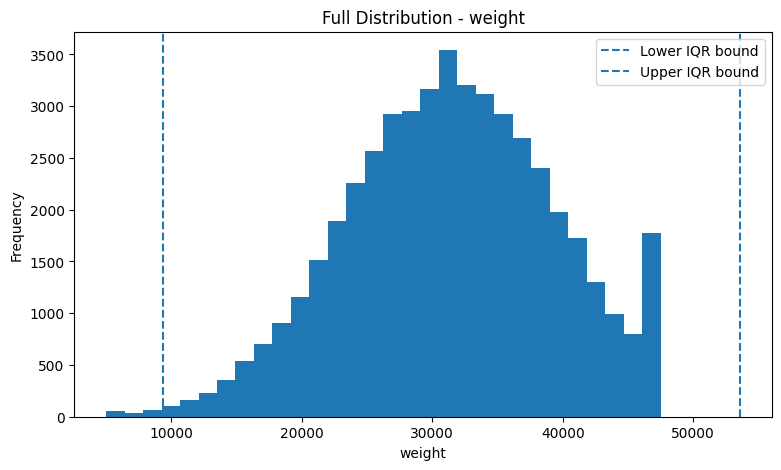

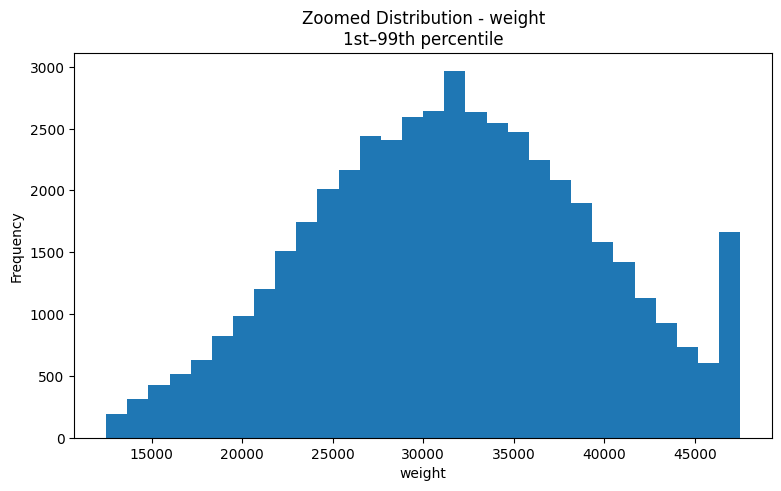


Feature: distance
Number of outliers: 32
Lower bound: -1092.29
Upper bound: 3288.21
Outlier values:
[3327.0, 3342.6, 3309.4, 3313.2, 3360.1, 3305.0, 3373.7, 3439.8, 3299.7, 3365.2, 3315.5, 3291.3, 3362.3, 3293.0, 3308.1, 3316.6, 3354.0, 3292.5, 3344.4, 3317.1, 3387.5, 3320.9, 3326.1, 3377.2, 3326.9, 3300.5, 3302.0, 3296.4, 3310.6, 3288.9, 3308.4, 3396.6]


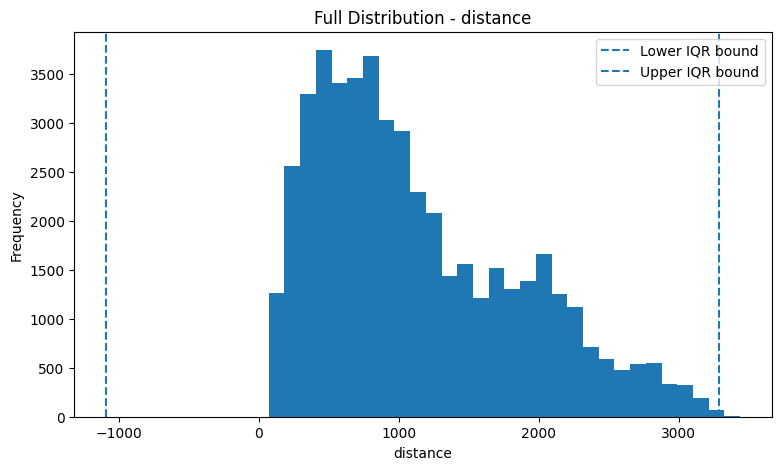

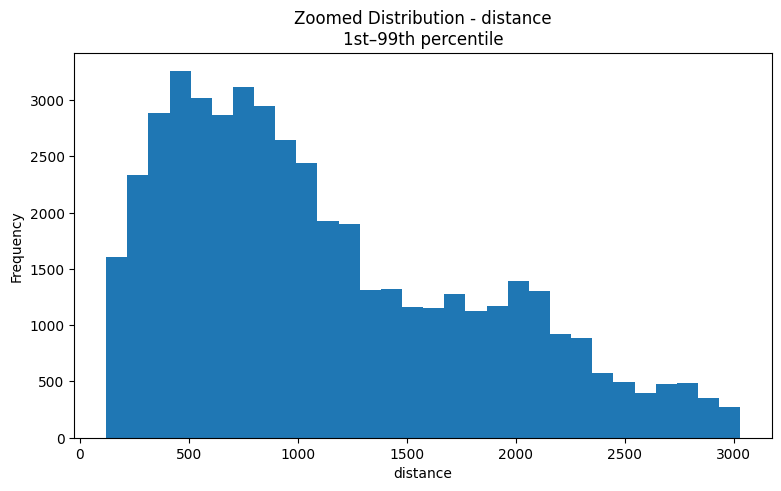

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

numeric_features = [
    'rpm',
    'posted_rate',
    'quote_signal',
    'market_index',
    'weight',
    'distance'
]

for column in numeric_features:

    data = pd.to_numeric(
        df_selected[column],
        errors='coerce'
    ).dropna().astype(float)

    # IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data < lower_bound) | (data > upper_bound)
    ]

    print(f"\n{'='*50}")
    print(f"Feature: {column}")
    print(f"Number of outliers: {len(outliers)}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print("Outlier values:")
    print(outliers.tolist())

    # -----------------------------
    # Full histogram
    # -----------------------------
    plt.figure(figsize=(9, 5))

    plt.hist(data, bins=30)

    plt.axvline(
        lower_bound,
        linestyle='--',
        label='Lower IQR bound'
    )

    plt.axvline(
        upper_bound,
        linestyle='--',
        label='Upper IQR bound'
    )

    plt.title(f'Full Distribution - {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

    # -----------------------------
    # Zoomed histogram
    # -----------------------------
    
    # Use 1st and 99th percentiles to remove extreme values
    zoom_min = data.quantile(0.01)
    zoom_max = data.quantile(0.99)

    zoomed_data = data[
        (data >= zoom_min) &
        (data <= zoom_max)
    ]

    plt.figure(figsize=(9, 5))

    plt.hist(zoomed_data, bins=30)

    plt.title(
        f'Zoomed Distribution - {column}\n'
        f'1st–99th percentile'
    )

    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

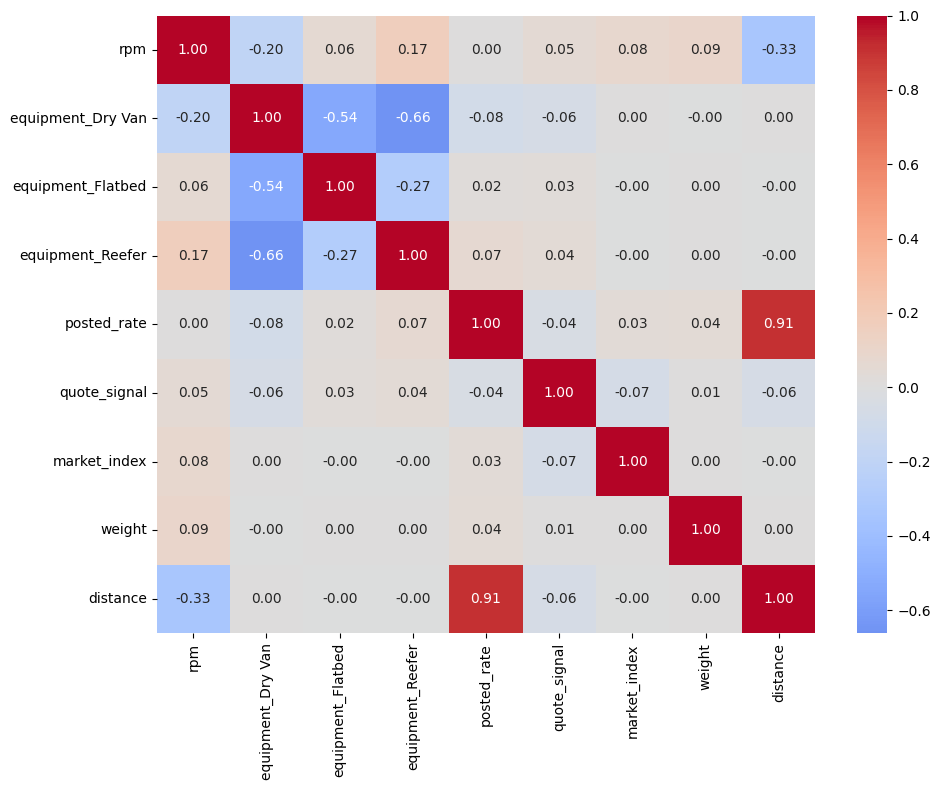

In [21]:
numeric_cols = df_selected.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df_selected[numeric_cols].corr()

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()